<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/Actividad_6_Descomposicion_y_STL_AlvaroHernandez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 6 · Descomposición de series temporales y diagnóstico con STL

**Curso:** Métodos para Pronóstico y Analítica Avanzada  
**Entorno:** Python en Google Colab  
**Caso:** solicitudes mensuales de una oficina institucional, 2022–2025

El propósito no es memorizar sintaxis. Cada bloque responde una pregunta analítica y el código está completo para que puedas concentrarte en **leer las gráficas, comprobar cálculos y justificar decisiones**.

Al finalizar podrás:

1. separar una serie en tendencia, estacionalidad y residuo;
2. distinguir descomposición aditiva y multiplicativa;
3. reproducir la lógica del método clásico;
4. aplicar STL y construir una serie ajustada estacionalmente;
5. comparar STL ordinario y robusto ante un evento extraordinario.


* Profesor: Mtro. César Alonso Rivas Flores
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* Fecha de entrega: 6 de octubre de 2026




## Cómo trabajar

- Ejecuta las celdas en orden con el botón ▶.
- Lee la pregunta antes de observar la salida.
- No cambies los datos originales; las simulaciones usan copias.
- Responde con evidencia. Evita frases como “se ve mejor” sin explicar qué cambió.
- Si aparece un error por ejecución desordenada, utiliza **Entorno de ejecución → Ejecutar todas**.


## 0. Preparación del entorno

Usaremos `pandas` para organizar los datos, `matplotlib` para visualizar y `statsmodels` para las descomposiciones. Google Colab incluye normalmente estas bibliotecas.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (12, 4.5), "font.size": 11})
print("Entorno preparado correctamente")


Entorno preparado correctamente


## 1. Construir la serie temporal

Una serie temporal necesita dos elementos: un valor y el momento al que pertenece. La frecuencia `MS` significa **inicio de mes**.


In [ ]:
valores = [82, 80, 76, 75, 70, 69, 63, 89, 88, 81, 77, 64, 96, 94, 90, 90, 85, 83, 77, 103, 102, 95, 91, 78, 108, 107, 103, 102, 97, 95, 89, 115, 114, 107, 103, 91, 123, 121, 117, 116, 111, 109, 103, 129, 128, 122, 118, 105]
fechas = pd.date_range("2022-01-01", periods=len(valores), freq="MS")
serie = pd.Series(valores, index=fechas, name="Solicitudes")

datos = serie.rename_axis("Mes").reset_index()
datos.head(), datos.tail()


(         Mes  Solicitudes
 0 2022-01-01           82
 1 2022-02-01           80
 2 2022-03-01           76
 3 2022-04-01           75
 4 2022-05-01           70,
           Mes  Solicitudes
 43 2025-08-01          129
 44 2025-09-01          128
 45 2025-10-01          122
 46 2025-11-01          118
 47 2025-12-01          105)

In [ ]:
print(f"Observaciones: {len(serie)}")
print(f"Inicio: {serie.index.min():%B %Y}")
print(f"Fin: {serie.index.max():%B %Y}")
print(f"Promedio: {serie.mean():.2f} solicitudes")


Observaciones: 48
Inicio: January 2022
Fin: December 2025
Promedio: 96.48 solicitudes


## 2. Primera lectura: ¿qué movimientos conviven?

Antes de descomponer, observa la serie completa. Busca crecimiento, repeticiones y eventos aislados.


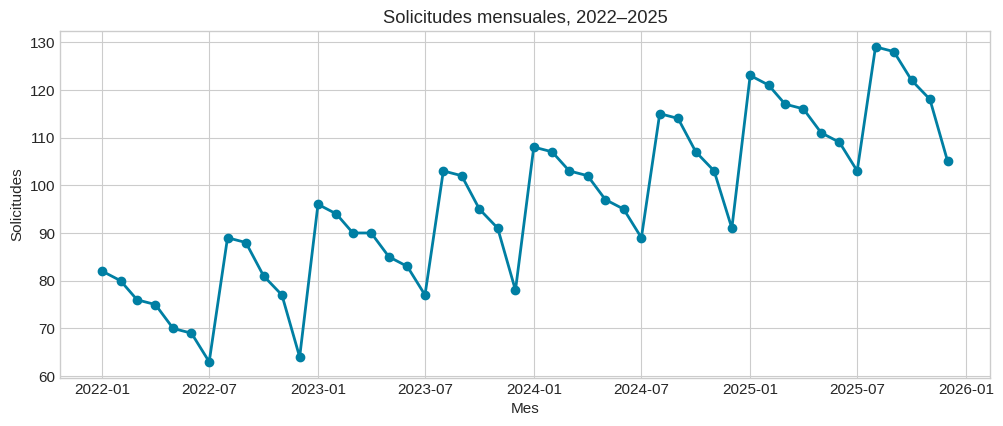

In [ ]:
fig, ax = plt.subplots()
ax.plot(serie.index, serie, color="#007FA3", marker="o", linewidth=2)
ax.set(title="Solicitudes mensuales, 2022–2025", xlabel="Mes", ylabel="Solicitudes")
plt.show()


**Preguntas**

1. ¿La base de la serie permanece igual o cambia entre 2022 y 2025?  
Presenta un crecimiento regular.
2. ¿Qué meses parecen repetirse como altos y cuáles como bajos?  
Los altos son enero,  agosto y septiembre, y los bajos junio, julio y diciembre
3. ¿Existe un solo movimiento o varios superpuestos?
La serie combina un patrón estacional que se repite cada año con una tendencia ascendente de fondo.


### Tu interpretación

Escribe aquí una respuesta completa. Cita al menos una gráfica, un mes o una medida.

**Respuesta:**
Se observa un comportamiento estacional claro, con picos en agosto y septiembre, y enero también alto. Los meses bajos son julio y diciembre, con junio cerca. Sobre ese patrón hay un crecimiento gradual de 2022 a 2025, así que la base no es constante.

## 3. Comparar los años sobre el mismo calendario

Superponer los años ayuda a reconocer si el patrón vuelve aproximadamente en la misma posición del ciclo.


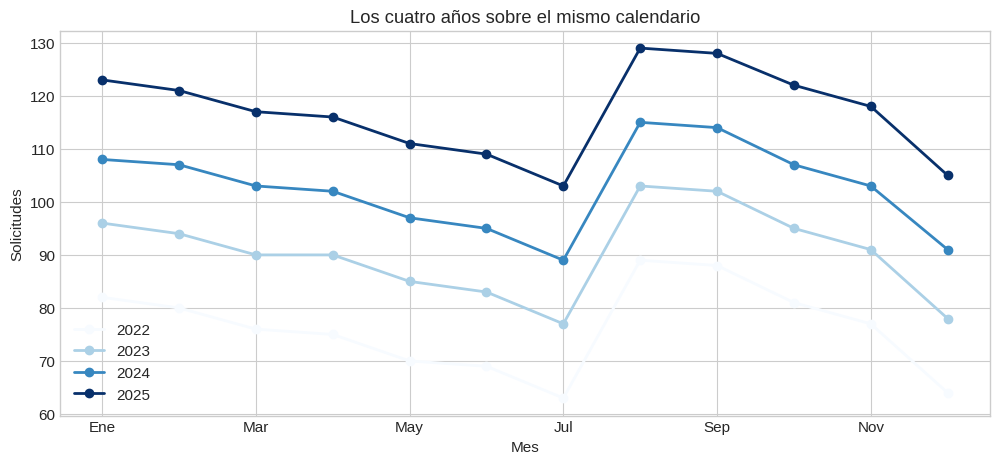

In [ ]:
tabla_anual = pd.DataFrame({
    anio: serie[serie.index.year == anio].to_numpy()
    for anio in sorted(serie.index.year.unique())
}, index=["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"])

ax = tabla_anual.plot(marker="o", linewidth=2, figsize=(12,5), colormap="Blues")
ax.set(title="Los cuatro años sobre el mismo calendario", xlabel="Mes", ylabel="Solicitudes")
plt.show()


**Pregunta:** ¿qué evidencia respalda utilizar un periodo estacional de 12 meses? Recuerda: datos mensuales no implican automáticamente un ciclo anual.
Al observar el dibujo de la gráfica es claro que la figura anual es muy similar cada año baja hasta el mes de julio tiene una subida en agosto y disminuye hasta diciembre.

### Tu interpretación

Escribe aquí una respuesta completa. Cita al menos una gráfica, un mes o una medida.

**Respuesta:**

La gráfica de los cuatro años superpuestos muestra una forma anual repetida. En los cuatro años, julio es el punto más bajo y agosto el más alto. El salto julio–agosto es de 26 solicitudes cada año. Después de agosto la serie desciende hasta diciembre. Esa repetición en los mismos meses respalda utilizar un periodo estacional de 12 meses.

## 4. Dos maneras de combinar componentes

En una representación aditiva:

$$Y_t=T_t+S_t+R_t$$

Todos los componentes se expresan en solicitudes. Un efecto estacional de `+12` agrega alrededor de doce solicitudes.

En una representación multiplicativa:

$$Y_t=T_t\times S_t\times R_t$$

La estación se expresa como factor. Un índice `1.15` representa cerca de 15 % por encima de la tendencia.

**Criterio gráfico:** si la amplitud del ciclo permanece parecida en unidades, suele ser razonable la aditiva; si crece proporcionalmente con el nivel, puede convenir la multiplicativa.


In [ ]:
amplitud_por_anio = tabla_anual.max() - tabla_anual.min()
resumen_amplitud = pd.DataFrame({
    "Mínimo": tabla_anual.min(),
    "Máximo": tabla_anual.max(),
    "Amplitud": amplitud_por_anio
})
resumen_amplitud


,Mínimo,Máximo,Amplitud
2022,63,89,26
2023,77,103,26
2024,89,115,26
2025,103,129,26


**Pregunta:** ¿la amplitud crece en proporción al nivel o permanece aproximadamente estable en solicitudes? ¿Qué variante utilizarías en esta práctica?
Permanece estable en solicitudes. La tabla muestra amplitud de 26 en los cuatro años. El nivel sube cada año y la distancia entre mínimo y máximo se mantiene igual. Por eso la representación aditiva es la más razonable para esta práctica.

### Tu interpretación

Escribe aquí una respuesta completa. Cita al menos una gráfica, un mes o una medida.

**Respuesta:**
La amplitud permanece aproximadamente estable en solicitudes. En la tabla se ve que los cuatro años tienen una amplitud de 26. Por ejemplo, en 2022 el mínimo es 63 y el máximo 89; en 2025 el mínimo es 103 y el máximo 129. El nivel general sube y la distancia entre julio y agosto se mantiene en 26 solicitudes. Así que usaría la variante aditiva, donde el efecto estacional se suma o resta en solicitudes.

# Parte I · Descomposición clásica

La descomposición clásica es útil para comprender el procedimiento:

1. estima la tendencia con una media móvil centrada;
2. retira la tendencia;
3. promedia posiciones equivalentes del ciclo para estimar la estación;
4. calcula el residuo.


## 5. Media móvil centrada de 12 meses

Como 12 es par, la tendencia queda entre dos meses. Para centrarla en $t$ usamos 13 observaciones con medio peso en los extremos:

$$CMA_t=\frac{0.5Y_{t-6}+Y_{t-5}+\cdots+Y_{t+5}+0.5Y_{t+6}}{12}$$

Esto deja seis meses sin tendencia al inicio y seis al final. No faltan datos: es una consecuencia del cálculo centrado.


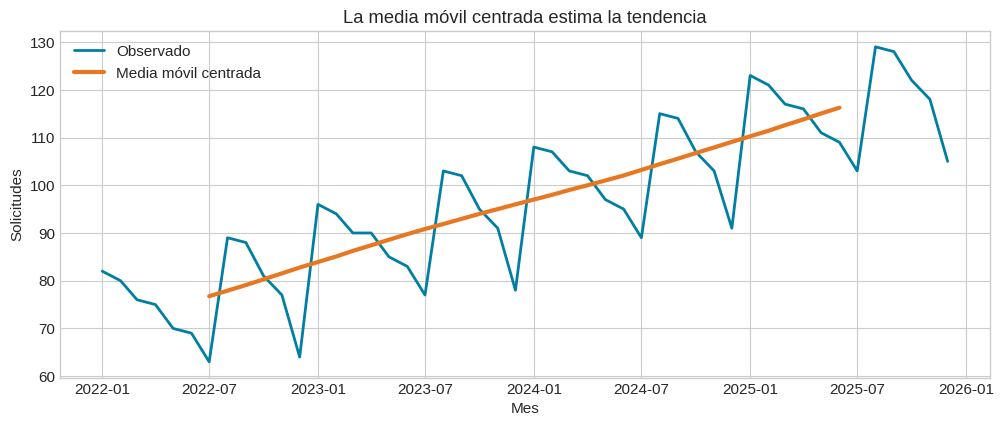

In [ ]:
pesos_cma = np.r_[0.5, np.ones(11), 0.5] / 12
valores_cma = np.convolve(serie.to_numpy(), pesos_cma, mode="valid")
tendencia_manual = pd.Series(valores_cma, index=serie.index[6:-6], name="Tendencia manual")

fig, ax = plt.subplots()
ax.plot(serie.index, serie, label="Observado", color="#007FA3", linewidth=2)
ax.plot(tendencia_manual.index, tendencia_manual, label="Media móvil centrada", color="#E87722", linewidth=3)
ax.set(title="La media móvil centrada estima la tendencia", xlabel="Mes", ylabel="Solicitudes")
ax.legend()
plt.show()


In [ ]:
enero_2024 = pd.Timestamp("2024-01-01")
print(f"Tendencia manual de enero 2024: {tendencia_manual.loc[enero_2024]:.2f}")
print("Meses con tendencia:", len(tendencia_manual), "de", len(serie))


Tendencia manual de enero 2024: 97.00
Meses con tendencia: 36 de 48


**Preguntas**

1. ¿Por qué la línea naranja empieza después y termina antes que la azul?

 La media móvil centrada de 12 meses usa 6 meses antes y 6 meses después del punto donde se quiere estimar la tendencia. Por eso deja sin tendencia los primeros 6 meses y los últimos 6 meses. En la gráfica, la línea naranja va de julio de 2022 a junio de 2025, con 36 puntos de 48.
2. ¿Este cálculo podría pronosticar diciembre de 2025? Explica usando la información que necesitaría.

Para calcular la tendencia centrada de diciembre de 2025 se necesitarían datos de enero a junio de 2026. Para usarlo como pronóstico, primero habría que estimar esos meses futuros.


### Tu interpretación

Escribe aquí una respuesta completa. Cita al menos una gráfica, un mes o una medida.

**Respuesta:**

La media móvil centrada de 12 meses estima la tendencia y deja fuera los primeros 6 meses y los últimos 6 meses de la serie. En la gráfica, la Media movil centrada comienza en julio de 2022 y termina en junio de 2025, con 36 observaciones de tendencia. Para diciembre de 2025 no se puede calcular esta tendencia con los datos actuales, porque la fórmula centrada requiere los valores de enero a junio de 2026. Así que este cálculo no pronostica diciembre de 2025 por sí solo; primero se tendrían que proyectar esos meses futuros.

## 6. Aplicar la descomposición clásica completa

`seasonal_decompose` automatiza la misma lógica. Usamos `model="additive"` y `period=12`.


In [ ]:
clasica = seasonal_decompose(serie, model="additive", period=12, extrapolate_trend=0)

componentes_clasicos = pd.DataFrame({
    "Observado": clasica.observed,
    "Tendencia": clasica.trend,
    "Estacionalidad": clasica.seasonal,
    "Residuo": clasica.resid
})
componentes_clasicos.loc["2024-01-01":"2024-03-01"].round(2)


,Observado,Tendencia,Estacionalidad,Residuo
2024-01-01,108.0,97.0,11.93,-0.93
2024-02-01,107.0,98.0,9.15,-0.15
2024-03-01,103.0,99.0,4.04,-0.04


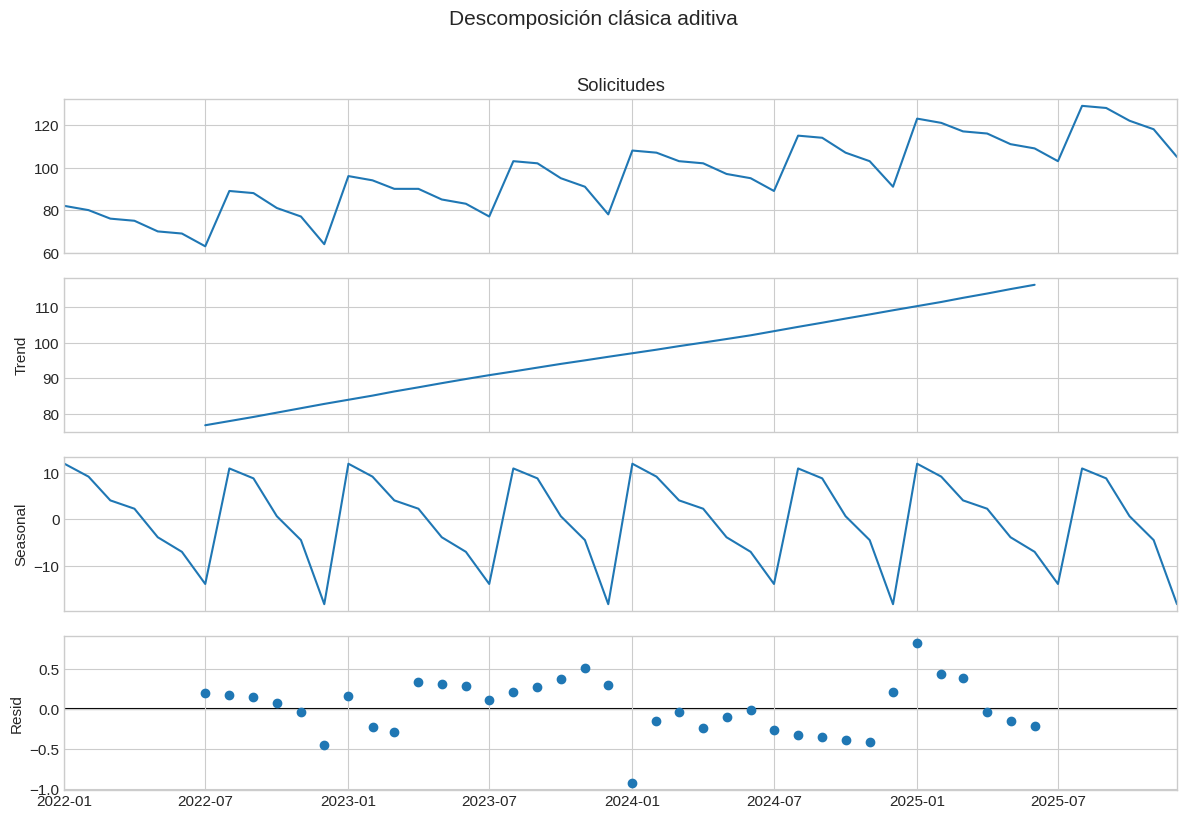

In [ ]:
fig = clasica.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Descomposición clásica aditiva", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()


## 7. Comprobar un mes manualmente

Para una descomposición aditiva:

$$R_t=Y_t-T_t-S_t$$

La suma $T_t+S_t$ es la parte explicada. La diferencia respecto a $Y_t$ es el residuo.


In [ ]:
fila = componentes_clasicos.loc[enero_2024]
comprobacion = pd.DataFrame({
    "Elemento": ["Observado Yₜ", "Tendencia Tₜ", "Estacionalidad Sₜ", "Tₜ + Sₜ", "Residuo Rₜ"],
    "Valor": [fila["Observado"], fila["Tendencia"], fila["Estacionalidad"],
              fila["Tendencia"] + fila["Estacionalidad"], fila["Residuo"]]
})
comprobacion.round(2)


,Elemento,Valor
0,Observado Yₜ,108.00
1,Tendencia Tₜ,97.00
2,Estacionalidad Sₜ,11.93
3,Tₜ + Sₜ,108.93
4,Residuo Rₜ,-0.93


In [ ]:
reconstruccion = clasica.trend + clasica.seasonal + clasica.resid
error_redondeo = (serie - reconstruccion).abs().dropna().max()
print(f"Máxima diferencia de reconstrucción: {error_redondeo:.10f}")


Máxima diferencia de reconstrucción: 0.0000000000


**Pregunta:** si el residuo de enero de 2024 es negativo, ¿qué significa? ¿Por qué no debe llamarse error de pronóstico?
Significa que el valor observado quedó 0.93 solicitudes por debajo de lo que marcan la tendencia y la estacionalidad. Ese faltante es el residuo negativo. No es error de pronóstico porque aquí no se está prediciendo un dato futuro.

### Tu interpretación

Escribe aquí una respuesta completa. Cita al menos una gráfica, un mes o una medida.

**Respuesta:**
El residuo de enero de 2024 es −0.93, así que la solicitud observada quedó  por debajo de la parte explicada por tendencia y estacionalidad: 97.00 + 11.93 = 108.93, frente a 108.00 observadas. No se considera error de pronóstico porque no se está pronosticando enero de 2024. La descomposición usa los datos observados para estimar los componentes. En la gráfica el residuo se mueve alrededor de cero, y la reconstrucción tiene una diferencia máxima de 0.0000000000, así que el residuo solo captura lo que el modelo aditivo no atribuye a tendencia ni a estacionalidad.

## 8. Construir la serie ajustada estacionalmente

En una representación aditiva:

$$A_t=Y_t-S_t$$

Esta operación retira el patrón mensual estimado. No elimina eventos reales y no produce automáticamente un pronóstico.


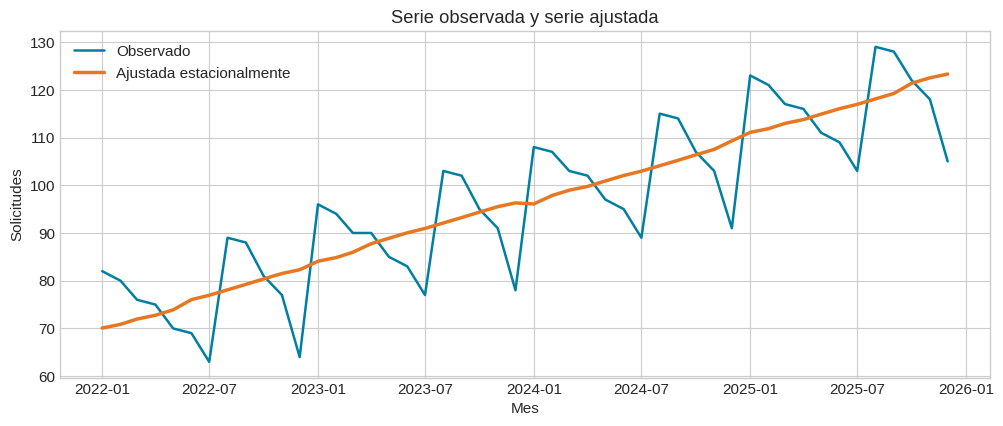

In [ ]:
ajustada_clasica = serie - clasica.seasonal

fig, ax = plt.subplots()
ax.plot(serie.index, serie, label="Observado", color="#007FA3", linewidth=1.8)
ax.plot(ajustada_clasica.index, ajustada_clasica, label="Ajustada estacionalmente", color="#E87722", linewidth=2.5)
ax.set(title="Serie observada y serie ajustada", xlabel="Mes", ylabel="Solicitudes")
ax.legend()
plt.show()


### Tu interpretación

Escribe aquí una respuesta completa. Cita al menos una gráfica, un mes o una medida.

**Respuesta:**

La serie ajustada estacionalmente se obtiene restando la estacionalidad estimada. En la gráfica se ve que lo Observado conserva los picos y valles que se repiten cada año, mientras la línea naranja los suaviza. Por ejemplo, en enero de 2024 el valor observado es 108.00 y la estacionalidad estimada es 11.93, así que la serie ajustada queda en 96.07. Ese valor queda muy cerca de la tendencia de 97.00 para ese mes. En meses bajos como julio, la estacionalidad es negativa, así que la serie ajustada queda por encima de la observada. La línea de la Ajustada intencionalmente todavía muestra el crecimiento general y algunos movimientos irregulares.

# Parte II · Descomposición STL

STL significa **Seasonal and Trend decomposition using Loess**. Usa regresiones locales para construir curvas suaves. Es más flexible que la descomposición clásica y puede reducir la influencia de observaciones atípicas.


## 9. Aplicar STL

- `period=12`: un ciclo contiene doce meses.
- `seasonal=13`: controla la suavidad estacional y debe ser impar.
- `robust=False`: primero realizamos el ajuste ordinario.


In [ ]:
stl = STL(serie, period=12, seasonal=13, robust=False)
resultado_stl = stl.fit()

componentes_stl = pd.DataFrame({
    "Observado": serie,
    "Tendencia": resultado_stl.trend,
    "Estacionalidad": resultado_stl.seasonal,
    "Residuo": resultado_stl.resid
})
componentes_stl.head().round(2)


,Observado,Tendencia,Estacionalidad,Residuo
2022-01-01,82,69.82,11.92,0.26
2022-02-01,80,70.98,8.85,0.18
2022-03-01,76,72.14,3.70,0.17
2022-04-01,75,73.30,1.94,-0.24
2022-05-01,70,74.47,-4.20,-0.26


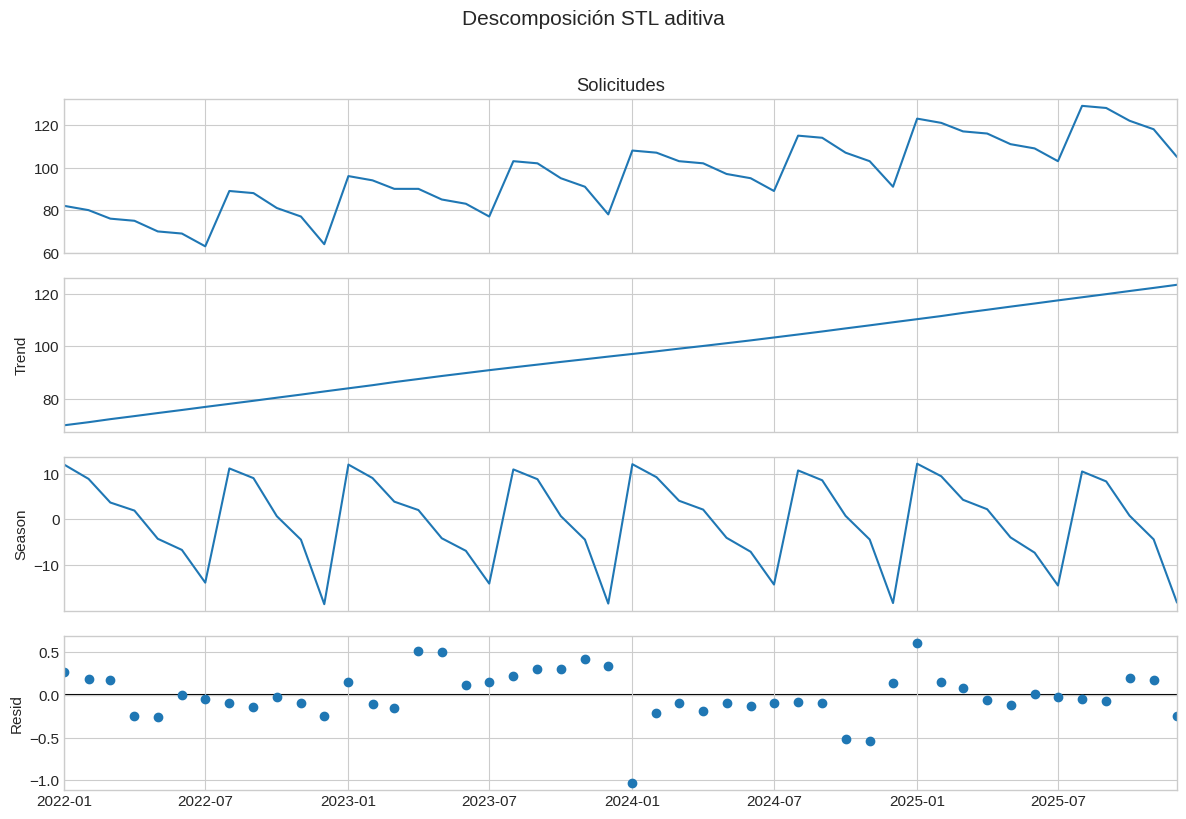

In [ ]:
fig = resultado_stl.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Descomposición STL aditiva", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()


**Preguntas**

1. ¿Qué información conserva la tendencia?  

La tendencia de STL conserva el movimiento general de la serie. En la tabla la tendencia de 2022 cambia de 69.82 (enero), a 70.98 (febrero), a 72.14 (marzo), a 73.30 (abril) y a 74.47 (mayo). La variación es suave. En la gráfica se muestra una curva ascendente de 2022 a 2025. Ahí está el crecimiento general, sin las subidas de agosto ni las bajadas de julio.

2. ¿Qué meses reciben efectos estacionales positivos y negativos?  

Con la tabla podemos observar el inicio del patrón. Enero tiene +11.92, febrero +8.85, marzo +3.70 y abril +1.94. Mayo ya es negativo, con −4.20. En la gráfica, el panel de estacionalidad repite la misma forma cada año. Los meses con efecto positivo son enero, febrero, marzo, abril, agosto, septiembre y probablemente octubre y noviembre. Los meses con efecto negativo son mayo, junio, julio y diciembre.

3. ¿Los residuos parecen conservar un patrón evidente?
No. En la tabla, los residuos de los primeros meses de 2022 son 0.26, 0.18, 0.17, −0.24 y −0.26. Son valores pequeños y alternan signo sin una dirección clara. En la gráfica, el panel de residuo se mueve alrededor de cero, sin una forma que se repita.


### Tu interpretación

Escribe aquí una respuesta completa. Cita al menos una gráfica, un mes o una medida.

**Respuesta:**

La descomposición STL separa la serie en tendencia, estacionalidad y residuo. La tendencia conserva el crecimiento de fondo, en la tabla `componentes_stl` va de 69.82 en enero de 2022 a 74.47 en mayo de 2022, y en la gráfica se observa que sube de 2022 a 2025. La estacionalidad conserva el patrón mensual: enero (+11.92), febrero (+8.85) y agosto son positivos, mientras mayo (−4.20), julio y diciembre son negativos. Los residuos son pequeños y se mueven alrededor de cero (0.26, 0.18, 0.17, −0.24, −0.26), sin un patrón evidente.



## 10. Perfil estacional y serie ajustada

Promediamos la estacionalidad estimada por nombre de mes para resumir el calendario. Después retiramos ese componente.


In [ ]:
perfil_estacional = (
    pd.DataFrame({"Mes": serie.index.month, "Efecto": resultado_stl.seasonal})
    .groupby("Mes")["Efecto"].mean()
)
perfil_estacional.index = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
perfil_estacional.round(2).to_frame("Efecto estacional")


,Efecto estacional
Ene,12.02
Feb,9.13
Mar,3.99
Abr,2.10
May,-4.04
Jun,-6.93
Jul,-14.07
Ago,10.79
Sep,8.66
Oct,0.77


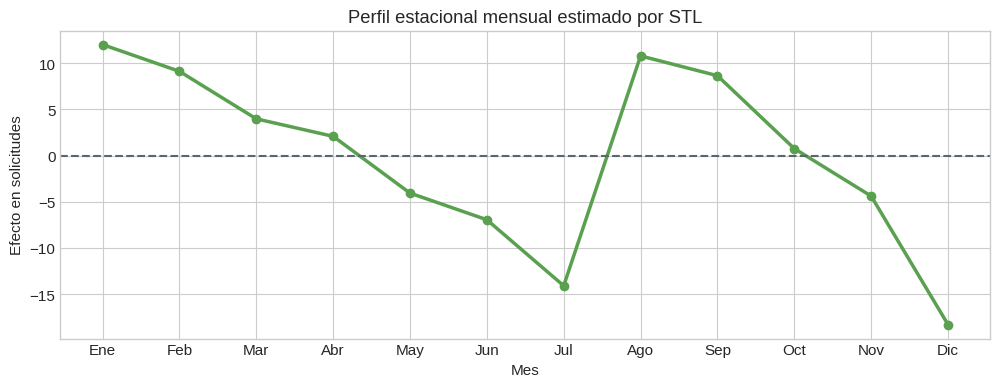

In [ ]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(perfil_estacional.index, perfil_estacional, color="#59A14F", marker="o", linewidth=2.5)
ax.axhline(0, color="#5B6570", linestyle="--")
ax.set(title="Perfil estacional mensual estimado por STL", xlabel="Mes", ylabel="Efecto en solicitudes")
plt.show()


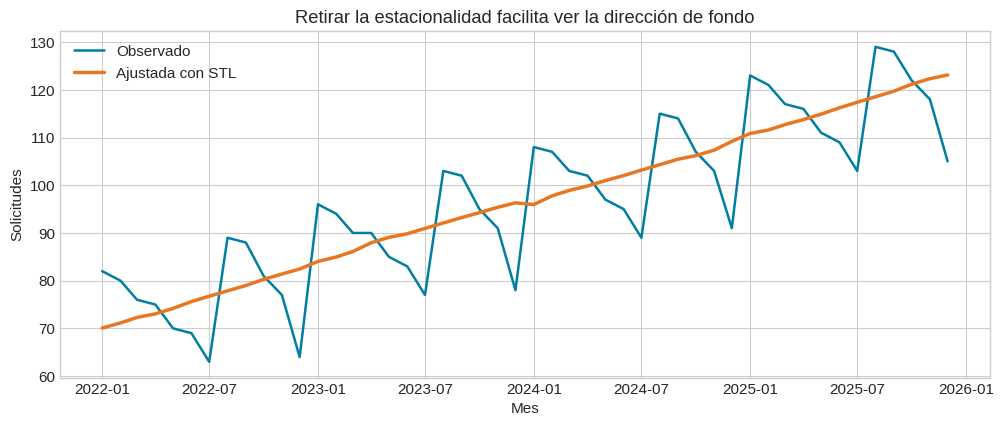

In [ ]:
ajustada_stl = serie - resultado_stl.seasonal

fig, ax = plt.subplots()
ax.plot(serie.index, serie, label="Observado", color="#007FA3", linewidth=1.8)
ax.plot(ajustada_stl.index, ajustada_stl, label="Ajustada con STL", color="#E87722", linewidth=2.5)
ax.set(title="Retirar la estacionalidad facilita ver la dirección de fondo", xlabel="Mes", ylabel="Solicitudes")
ax.legend()
plt.show()


**Pregunta:** ¿qué patrón desaparece y cuál permanece después del ajuste estacional?

Desaparece el patrón de subidas y bajadas cada 5 y 7 meses. En el ajuste estacional mensual estimado por STL se ve el patrón que se repite cada año,  julio y diciembre son los meses que más jalan hacia abajo, enero y agosto los que más impactan hacia arriba. Al restar ese componente en la serie ajustada las variaciones se suavizan. Lo que permanece es la dirección de general, subiendo.

### Tu interpretación

Escribe aquí una respuesta completa. Cita al menos una gráfica, un mes o una medida.

**Respuesta:**

El ajuste estacional con STL quita el patrón mensual estimado. En el perfil estacional se ve el calendario: enero (+12.02), agosto (+10.79) y septiembre (+8.66) empujan hacia arriba, mientras julio (−14.07) y diciembre (−18.26) jalan hacia abajo. Al restar ese componente, en la gráfica “Retirar la estacionalidad facilita ver la dirección de fondo” la línea naranja pierde el movimiento de cada 5 y 7 meses y conserva el crecimiento de general ascendente de 2022 a 2025. Eso nos confirma que la serie combina estacionalidad anual con un movimiento generalizado creciente.

## 11. Diagnóstico descriptivo de los residuos

Un residuo deseable oscila alrededor de cero y no conserva una estructura visible. Sin embargo, **media cercana a cero no demuestra ruido blanco**.


In [ ]:
residuos = resultado_stl.resid
diagnostico = pd.Series({
    "Media": residuos.mean(),
    "Desviación estándar": residuos.std(ddof=1),
    "Máximo absoluto": residuos.abs().max(),
    "Correlación rezago 1": residuos.autocorr(lag=1),
    "Correlación rezago 12": residuos.autocorr(lag=12)
})
diagnostico.round(4).to_frame("Valor")


,Valor
Media,-0.0045
Desviación estándar,0.2841
Máximo absoluto,1.0307
Correlación rezago 1,0.3240
Correlación rezago 12,-0.5918


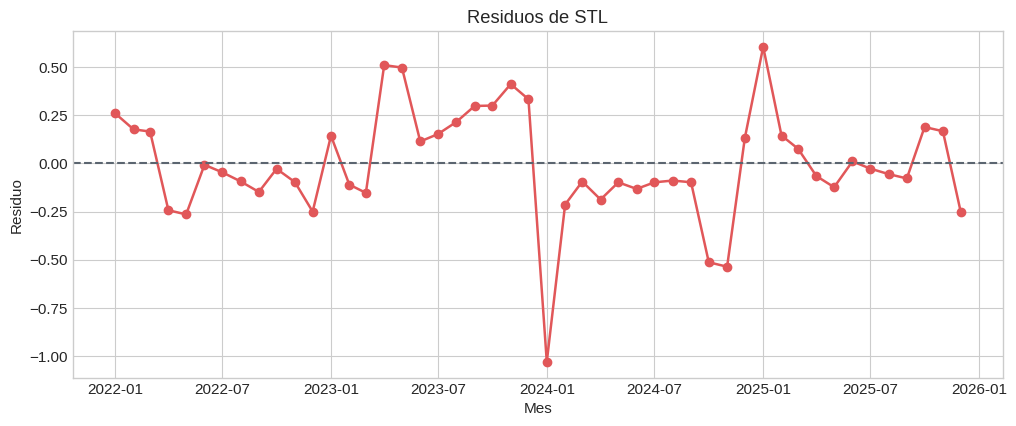

In [ ]:
fig, ax = plt.subplots()
ax.plot(residuos.index, residuos, color="#E15759", marker="o", linewidth=1.8)
ax.axhline(0, color="#5B6570", linestyle="--")
ax.set(title="Residuos de STL", xlabel="Mes", ylabel="Residuo")
plt.show()


**Pregunta:** ¿qué puedes afirmar con esta revisión y qué todavía no puedes afirmar?

Con esta revisión puedo afirmar que los residuos oscilan alrededor de cero y que su dispersión es pequeña. La media es −0.0045, la desviación estándar es 0.2841 y el máximo absoluto es de 1.0307. En la gráfica la línea roja se mueve cerca de la línea punteada de cero, sin saltos grandes. Eso indica que la tendencia y la estacionalidad capturaron lo principal.

No puedo afirmar que los residuos sean ruido blanco. La correlación de rezago 1 es 0.3240 y la de rezago 12 es −0.5918. Esos valores se deben tomar en cuenta. El rezago 1 nos dice que un residuo se parece un poco al del mes anterior. El rezago 12, con signo negativo, nos dice que queda algo del ciclo anual sin capturar, pero con signo contrario al que estimó STL. Tampoco puedo afirmar que el modelo sea adecuado.

### Tu interpretación

Escribe aquí una respuesta completa. Cita al menos una gráfica, un mes o una medida.

**Respuesta:**

Los residuos de STL tienen media prácticamente cero (−0.0045), desviación estándar pequeña (0.2841) y máximo absoluto de 1.0307. En la gráfica se mueven alrededor de cero sin saltos grandes, así que la descomposición capturó lo principal. Con eso puedo afirmar que la tendencia y la estacionalidad explican bien el nivel general de la serie. No puedo afirmar que sean ruido blanco ya que la correlación de rezago 1 es 0.3240 y la de rezago 12 es −0.5918, valores que indican estructura remanente. El rezago 12 negativo nos indica que aún queda algo del ciclo anual sin capturar. No puedo concluir que el modelo sea adecuado.

# Parte III · Un evento extraordinario y STL robusto

Agregaremos **35 solicitudes** a septiembre de 2024 para observar cómo un evento aislado puede repartirse entre tendencia, estación y residuo. La serie original permanecerá intacta.


In [ ]:
serie_evento = serie.copy()
mes_evento = pd.Timestamp("2024-09-01")
serie_evento.loc[mes_evento] += 35

print("Original:", serie.loc[mes_evento])
print("Serie simulada:", serie_evento.loc[mes_evento])


Original: 114
Serie simulada: 149


## 12. Comparar ajuste ordinario y robusto

`robust=True` asigna menor peso durante el ajuste a observaciones muy alejadas del patrón. No borra el dato ni explica su causa.


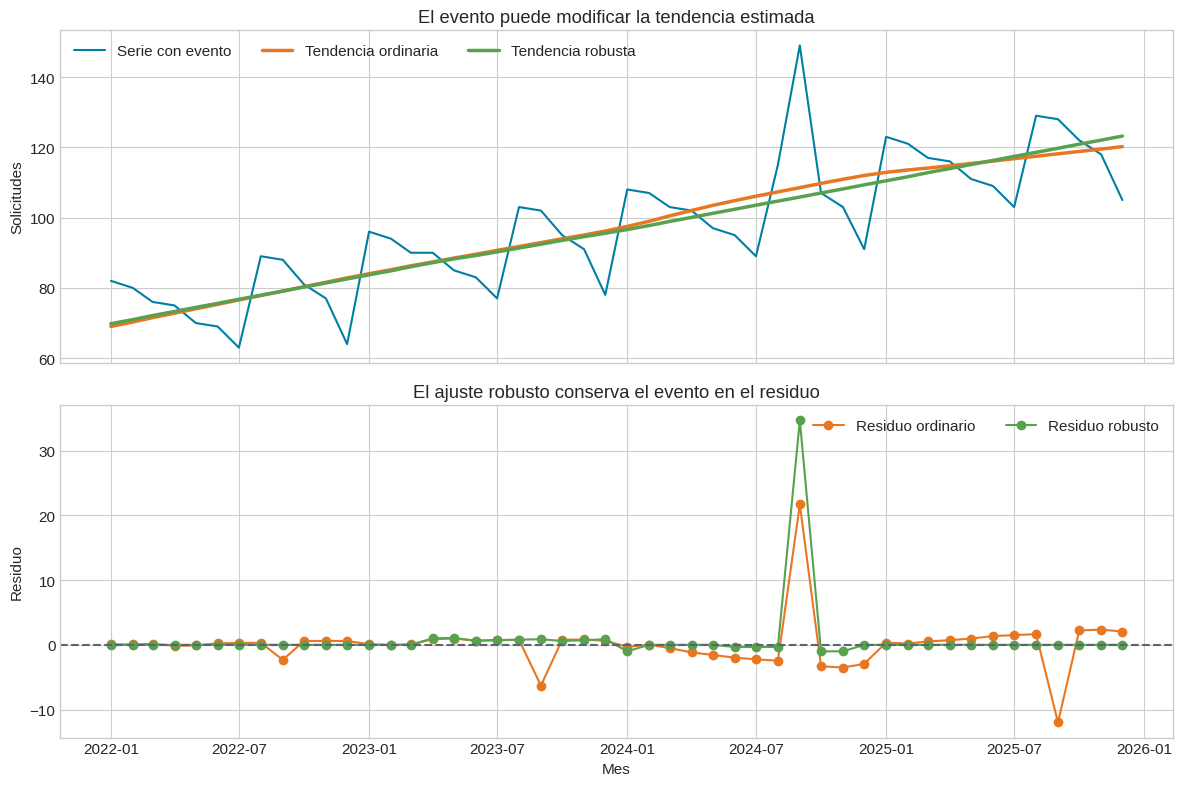

In [ ]:
ordinario = STL(serie_evento, period=12, seasonal=13, robust=False).fit()
robusto = STL(serie_evento, period=12, seasonal=13, robust=True).fit()

fig, axes = plt.subplots(2, 1, figsize=(12,8), sharex=True)
axes[0].plot(serie_evento.index, serie_evento, color="#007FA3", label="Serie con evento")
axes[0].plot(ordinario.trend.index, ordinario.trend, color="#E87722", linewidth=2.5, label="Tendencia ordinaria")
axes[0].plot(robusto.trend.index, robusto.trend, color="#59A14F", linewidth=2.5, label="Tendencia robusta")
axes[0].set(title="El evento puede modificar la tendencia estimada", ylabel="Solicitudes")
axes[0].legend(ncol=3)

axes[1].plot(ordinario.resid.index, ordinario.resid, color="#E87722", marker="o", label="Residuo ordinario")
axes[1].plot(robusto.resid.index, robusto.resid, color="#59A14F", marker="o", label="Residuo robusto")
axes[1].axhline(0, color="#5B6570", linestyle="--")
axes[1].set(title="El ajuste robusto conserva el evento en el residuo", xlabel="Mes", ylabel="Residuo")
axes[1].legend(ncol=2)
plt.tight_layout()
plt.show()


In [ ]:
comparacion_evento = pd.DataFrame({
    "Ordinario": [ordinario.trend.loc[mes_evento], ordinario.seasonal.loc[mes_evento], ordinario.resid.loc[mes_evento]],
    "Robusto": [robusto.trend.loc[mes_evento], robusto.seasonal.loc[mes_evento], robusto.resid.loc[mes_evento]]
}, index=["Tendencia", "Estacionalidad", "Residuo"])
comparacion_evento.round(2)


,Ordinario,Robusto
Tendencia,108.52,105.85
Estacionalidad,18.80,8.49
Residuo,21.68,34.66


In [ ]:
peso_evento = robusto.weights.loc[mes_evento]
print(f"Peso robusto asignado a septiembre de 2024: {peso_evento:.4f}")


Peso robusto asignado a septiembre de 2024: 0.0000


**Preguntas**

1. ¿Cuál ajuste absorbe más del evento en tendencia y estacionalidad?  

El ajuste ordinario. En la gráfica 1 la tendencia ordinaria se levanta más en septiembre de 2024 que la tendencia robusta. El ordinario reparte parte del aumento de 35 solicitudes entre tendencia y estación. El robusto casi no lo deja pasar a esos dos componentes.


2. ¿Por qué el residuo robusto es mayor?  

Porque el ajuste robusto le asigna peso cero a septiembre de 2024. Eso significa que ese mes no jala la tendencia ni la estacionalidad. Entonces casi todo el aumento se queda en el residuo: 34.66 en robusto contra 21.68 en ordinario.

3. ¿Qué información institucional investigarías antes de decidir qué hacer con el dato?

Investigaría qué pasó en septiembre de 2024 en la oficina. Para saber si hubo un cambio de sistema, un cierre temporal, una reforma o un evento externo que disparó solicitudes. También revisaría si el dato está bien capturado o si hay un error de registro. También indagaría si ese aumento es algo que puede repetirse, porque si es un evento recurrente tal vez deba tratarse distinto que si fue algo de una sola vez.


### Tu interpretación

Escribe aquí una respuesta completa. Cita al menos una gráfica, un mes o una medida.

**Respuesta:**

Al agregar 35 solicitudes a septiembre de 2024, el ajuste ordinario reparte parte del golpe entre tendencia y estacionalidad, la tendencia queda en 108.52 y la estacionalidad en 18.80. El ajuste robusto casi no lo deja pasar: tendencia 105.85 y estacionalidad 8.49, porque le asigna peso cero a ese mes. Por eso el residuo robusto es mayor, 34.66 contra 21.68 del ordinario. El ajuste robusto protege tendencia y estacionalidad de un evento aislado, pero no dice qué pasó ni por qué. Antes de decidir qué hacer con el dato investigaría la causa institucional del aumento, si fue un error de registro o un evento real, y si puede repetirse.

## 13. Mini-simulador de STL

Esta función permite comparar `period` y `robust`. En esta serie el periodo defendible es 12; cambiarlo es un experimento para observar consecuencias, no una selección automática.


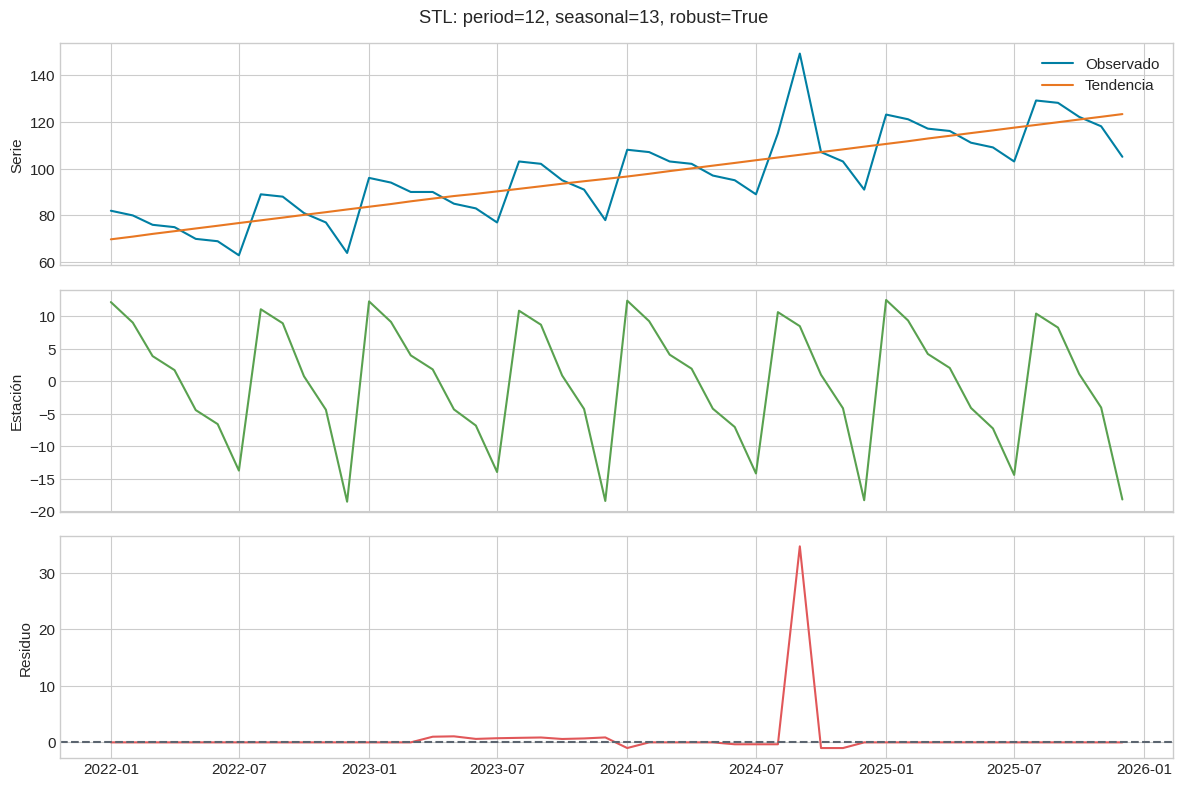

In [ ]:
def simular_stl(periodo=12, ventana_estacional=13, robusto=False):
    ajuste = STL(serie_evento, period=periodo, seasonal=ventana_estacional, robust=robusto).fit()
    fig, axes = plt.subplots(3, 1, figsize=(12,8), sharex=True)
    axes[0].plot(serie_evento.index, serie_evento, color="#007FA3", label="Observado")
    axes[0].plot(ajuste.trend.index, ajuste.trend, color="#E87722", label="Tendencia")
    axes[0].legend(); axes[0].set_ylabel("Serie")
    axes[1].plot(ajuste.seasonal.index, ajuste.seasonal, color="#59A14F"); axes[1].set_ylabel("Estación")
    axes[2].plot(ajuste.resid.index, ajuste.resid, color="#E15759"); axes[2].axhline(0,color="#5B6570",ls="--"); axes[2].set_ylabel("Residuo")
    fig.suptitle(f"STL: period={periodo}, seasonal={ventana_estacional}, robust={robusto}")
    plt.tight_layout(); plt.show()
    return ajuste

simulacion = simular_stl(periodo=12, ventana_estacional=13, robusto=True)


### Experimentos sugeridos

Ejecuta uno por vez y vuelve después a la configuración contextualizada.

```python
simular_stl(periodo=12, ventana_estacional=7, robusto=False)
simular_stl(periodo=12, ventana_estacional=25, robusto=False)
simular_stl(periodo=12, ventana_estacional=13, robusto=True)
```

Describe qué componente se vuelve más suave y dónde aparece el evento.

La ventana estacional controla qué tan suave sale la estacionalidad. Con `ventana_estacional=7` la estacionalidad se vuelve más flexible y ondulada. Con `ventana_estacional=25` sale más suave y estable. Con `robusto=True` la tendencia y la estacionalidad se mantienen limpias, y el evento de septiembre de 2024 se queda casi completo en el residuo.

El evento aparece en septiembre de 2024, donde se sumaron 35 solicitudes. En la configuración ordinaria con ventana 7, ese pico se reparte más entre estacionalidad y residuo. En la configuración ordinaria con ventana 25, la estacionalidad es más rígida y el evento se nota más en tendencia y residuo. En la configuración robusta, el peso de ese mes es cero y el pico queda concentrado en el residuo.


### Tu interpretación

Escribe aquí una respuesta completa. Cita al menos una gráfica, un mes o una medida.

**Respuesta:**

El mini-simulador muestra que `seasonal` controla la suavidad del componente estacional. Con `seasonal=7` la línea verde de estacionalidad se ve más ondulada. Con `seasonal=25` se ve más plana y estable. En los dos casos ordinarios, el evento de septiembre de 2024 se reparte entre tendencia, estacionalidad y residuo. Con `robust=True` y `seasonal=13`, la tendencia y la estacionalidad se mantienen sin el golpe del evento, y el pico aparece casi completo en el residuo de septiembre de 2024. En la gráfica del simulador robusto, el panel de residuo muestra ese pico como el punto más alto de la serie. La configuración contextualizada para esta práctica es `period=12`, `seasonal=13` y `robust=True`, porque respeta el ciclo anual y protege los componentes principales ante el evento aislado.

# 14. Conclusión integradora

Redacta entre **150 y 200 palabras**. Tu conclusión debe incluir:

1. evidencia del ciclo de 12 meses;
2. interpretación de tendencia y estacionalidad;
3. qué desaparece en la serie ajustada;
4. una observación sobre los residuos;
5. qué cambió con `robust=True`;
6. una limitación o información externa necesaria.


### Tu interpretación

Escribe aquí una respuesta completa. Cita al menos una gráfica, un mes o una medida.

**Respuesta:**

La serie de solicitudes 2022–2025 muestra un ciclo anual claro. La amplitud se mantiene en 26 solicitudes los cuatro años, con julio como mínimo y agosto como máximo. Eso respalda usar `period=12`. La tendencia sube de forma sostenida, de alrededor de 70 a 105 solicitudes. La estacionalidad estimada por STL tiene enero en +12.02, agosto en +10.79, julio en −14.07 y diciembre en −18.26. Al restar ese componente, en la serie ajustada desaparece el vaivén mensual y permanece la dirección general. Los residuos tienen media −0.0045 y desviación estándar 0.2841, así que oscilan cerca de cero. La correlación de rezago 1 es 0.3240 y la de rezago 12 es −0.5918, señal de que aún queda estructura. Con `robust=True`, septiembre de 2024 recibe peso 0.000, el evento se queda en el residuo (34.66 contra 21.68 del ordinario) y la tendencia y la estacionalidad no se contaminan. Falta información institucional sobre la causa del pico.

## Lista de comprobación

- [ ] Ejecuté todas las celdas sin errores.
- [ ] Justifiqué `period=12` con contexto y evidencia gráfica.
- [ ] Distinguí serie ajustada, residuo y error de pronóstico.
- [ ] Comprobé la reconstrucción aditiva.
- [ ] Conservé la serie original antes de simular el evento.
- [ ] Mi conclusión incluye evidencia y una limitación.

## Fuentes

- Hyndman y Athanasopoulos, *Forecasting: Principles and Practice*: https://otexts.com/fpp3/stl.html
- Descomposición clásica: https://otexts.com/fpp3/classical-decomposition.html
- Ejemplo oficial de STL en statsmodels: https://www.statsmodels.org/stable/examples/notebooks/generated/stl_decomposition.html
- API de STL: https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.STL.html
